# Лабораторная работа "Декодирование DTMF сигнала"

### Задача:
С помощью алгоритма Герцеля декодировать сигнал и восстановить исходную последовательность

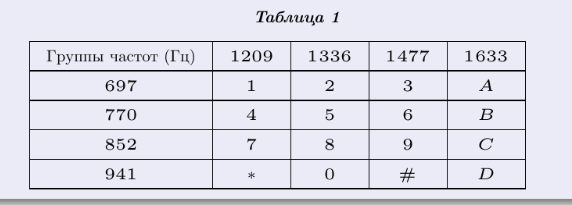

In [1]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

Составим таблицу соответствия пар частот символу на телефоне:

In [2]:
LOW_FREQS = [697, 770, 852, 941]
HIGH_FREQS = [1209, 1336, 1477, 1633]

DTMF_MAP = {
    (697, 1209): '1', (697, 1336): '2', (697, 1477): '3', (697, 1633): 'A',
    (770, 1209): '4', (770, 1336): '5', (770, 1477): '6', (770, 1633): 'B',
    (852, 1209): '7', (852, 1336): '8', (852, 1477): '9', (852, 1633): 'C',
    (941, 1209): '*', (941, 1336): '0', (941, 1477): '#', (941, 1633): 'D'
}

Реализуем алгоритм Герцеля:

In [3]:
def goertzel_mag(samples, target_freq, sample_rate):
    N = len(samples)
    k = int(target_freq * N / sample_rate)
    w = 2 * np.pi * k / N
    cosine = np.cos(w)
    coeff = 2 * cosine
    s_prev = 0
    s_prev2 = 0
    
    for x in samples:
        s = x + coeff * s_prev - s_prev2
        s_prev2 = s_prev
        s_prev = s
        
    power = s_prev**2 + s_prev2**2 - coeff * s_prev * s_prev2
    
    return power

Загружаем сигнал:

In [4]:
fs, data = wav.read('DTMF_Lab9.wav')
data = data / np.max(np.abs(data))

Построим осциллограмму последовательности:

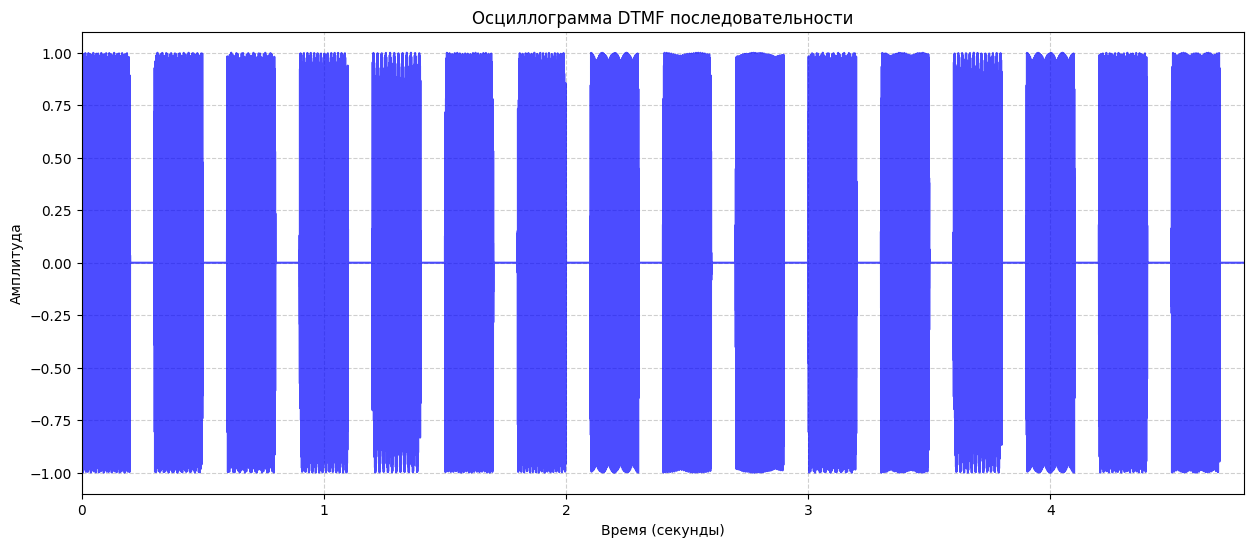

In [5]:
duration = len(data) / fs
time_axis = np.linspace(0, duration, len(data))

plt.figure(figsize=(15, 6))
plt.plot(time_axis, data, color='blue', alpha=0.7)

plt.title("Осциллограмма DTMF последовательности")
plt.xlabel("Время (секунды)")
plt.ylabel("Амплитуда")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xlim(0, duration)

plt.show()

Для наглядности построим осциллограмму первых 0.02 секунд сигнала:

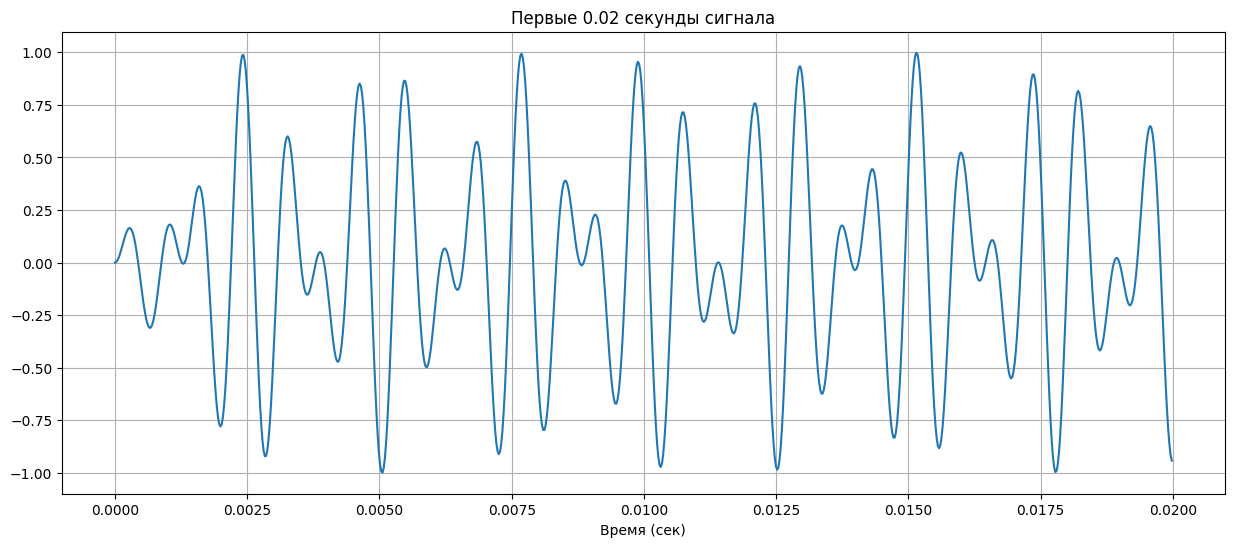

In [6]:
limit_sec_micro = 0.02 
limit_samples_micro = int(limit_sec_micro * fs)

t_micro = time_axis[:limit_samples_micro]
d_micro = data[:limit_samples_micro]

plt.figure(figsize=(15, 6))
plt.plot(t_micro, d_micro)
plt.title("Первые 0.02 секунды сигнала")
plt.xlabel("Время (сек)")
plt.grid(True)
plt.show()

Настраиваем временные интервалы:

In [7]:
tone_duration_sec = 0.200
pause_duration_sec = 0.100

tone_len = int(tone_duration_sec * fs)
pause_len = int(pause_duration_sec * fs)
cycle_len = tone_len + pause_len

Проходим по сигналу шагами по (200+100) мс:

In [8]:
num_symbols = len(data) // cycle_len

print(f"Частота дискретизации: {fs} Гц")
print(f"Длина тона: {tone_len} отсчетов")
print(f"Всего символов для анализа: {num_symbols}")

Частота дискретизации: 44100 Гц
Длина тона: 8820 отсчетов
Всего символов для анализа: 16


Проходимся по всему сигналу, ищем самую мощную нижнюю и верхнюю частоту для каждого временного интервала

In [9]:
decoded_sequence = []

for i in range(num_symbols):
    start = i * cycle_len
    end = start + tone_len
    segment = data[start:end]
    
    best_low_freq = None
    max_low_power = -1
    
    for f in LOW_FREQS:
        p = goertzel_mag(segment, f, fs)
        if p > max_low_power:
            max_low_power = p
            best_low_freq = f
            
    best_high_freq = None
    max_high_power = -1
    
    for f in HIGH_FREQS:
        p = goertzel_mag(segment, f, fs)
        if p > max_high_power:
            max_high_power = p
            best_high_freq = f
            

    symbol = DTMF_MAP.get((best_low_freq, best_high_freq), '?')
    decoded_sequence.append(symbol)
    print(f"Символ {i+1}: {symbol} (Нижний тон={best_low_freq}, Верхний тон={best_high_freq})")

print("Восстановленная последовательность:", "".join(decoded_sequence))

Символ 1: 0 (Нижний тон=941, Верхний тон=1336)
Символ 2: D (Нижний тон=941, Верхний тон=1633)
Символ 3: 1 (Нижний тон=697, Верхний тон=1209)
Символ 4: C (Нижний тон=852, Верхний тон=1633)
Символ 5: 2 (Нижний тон=697, Верхний тон=1336)
Символ 6: B (Нижний тон=770, Верхний тон=1633)
Символ 7: 3 (Нижний тон=697, Верхний тон=1477)
Символ 8: A (Нижний тон=697, Верхний тон=1633)
Символ 9: 4 (Нижний тон=770, Верхний тон=1209)
Символ 10: * (Нижний тон=941, Верхний тон=1209)
Символ 11: 5 (Нижний тон=770, Верхний тон=1336)
Символ 12: # (Нижний тон=941, Верхний тон=1477)
Символ 13: 6 (Нижний тон=770, Верхний тон=1477)
Символ 14: A (Нижний тон=697, Верхний тон=1633)
Символ 15: 7 (Нижний тон=852, Верхний тон=1209)
Символ 16: 8 (Нижний тон=852, Верхний тон=1336)
Восстановленная последовательность: 0D1C2B3A4*5#6A78


### Восстановленная последовательность: 0D1C2B3A4*5#6A78

### Вывод:
Алгоритм Герцеля показал себя как эффективный инструмент для нахождения известных частот в сигнале. Для задач, где мы ищем из ограниченного заранее известного набора частот, он оказывается выгоднее и проще, чем FFT.